# Hourly Bike Demand Forecasting using Time Series Modeling
**Author: Antigravity**
**Date: June 2026**

This notebook presents a comprehensive, presentation-ready time series modeling workflow to forecast hourly bike-sharing demand. It walks through exploratory data analysis (EDA), stationarity checking, decomposition, anomaly detection, feature engineering, and evaluation of multiple forecasting models against a baseline.


## Section 1: Setup & Data Preparation
First, we load the required libraries, set the visual style, and prepare the dataset.
We use the **UCI Bike Sharing Dataset** (specifically `hour.csv` containing hourly records for 2011-2012).


In [1]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import xgboost as xgb

# Ensure data directory exists
os.makedirs("data", exist_ok=True)
data_path = os.path.join("data", "hour.csv")

# Auto-download if dataset is missing (e.g. running in Colab or different working directory)
if not os.path.exists(data_path):
    print("Dataset not found locally. Downloading from UCI Machine Learning Repository...")
    url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
    zip_path = "bike_sharing_dataset.zip"
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extract("hour.csv", "data")
        os.remove(zip_path)
        print("Dataset downloaded and extracted successfully!")
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("Please ensure you run this notebook in the directory containing the 'data' folder or download the dataset manually.")

# Load the dataset
df = pd.read_csv(data_path)

# Set seaborn theme and plot params
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# Combine 'dteday' and 'hr' to create a unified datetime index
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')
df = df.sort_values('datetime').set_index('datetime')

print(f"Dataset Loaded. Shape: {df.shape}")
print(f"Time Series Range: {df.index.min()} to {df.index.max()}")
df.head()


Dataset Loaded. Shape: (17379, 17)
Time Series Range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
datetime,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Section 2: Exploratory Data Analysis (EDA)
Understanding patterns, seasonality, trends, and properties of the time series is key to engineering predictive features and selecting models.


### 2.1 Global Trend Visualization


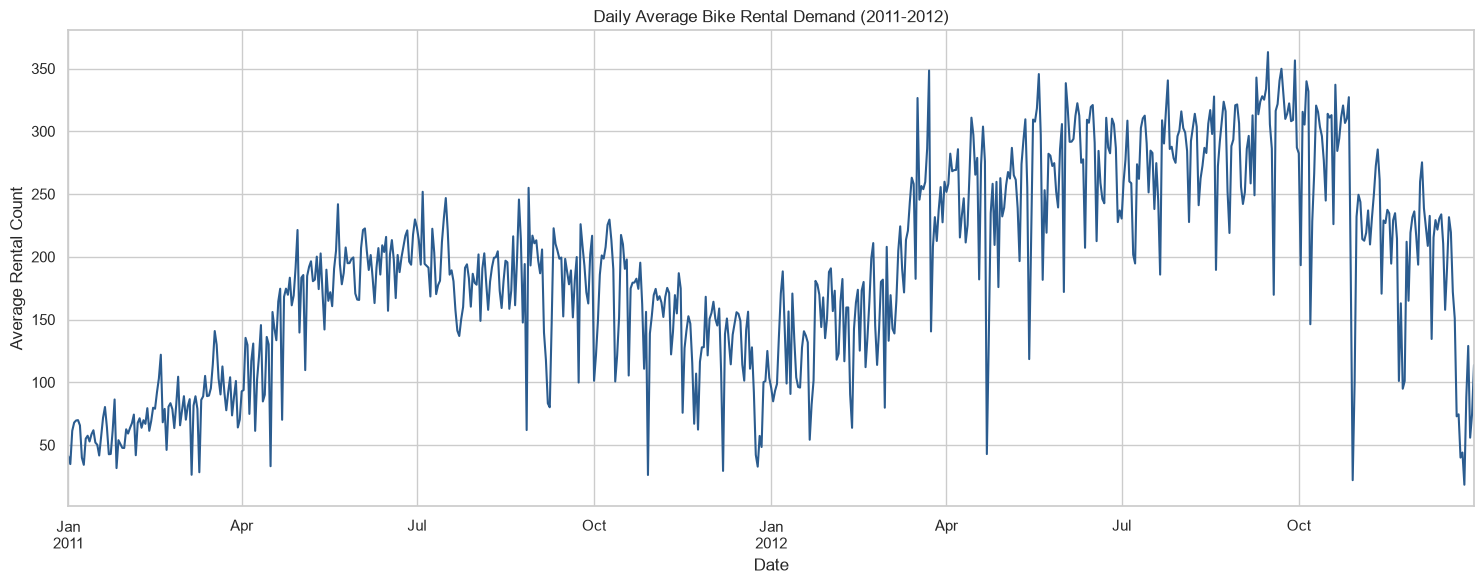

In [2]:
plt.figure(figsize=(15, 6))
df['cnt'].resample('D').mean().plot(color='#2b5c8f', linewidth=1.5)
plt.title('Daily Average Bike Rental Demand (2011-2012)')
plt.ylabel('Average Rental Count')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


### 2.2 Sub-Daily & Seasonal Boxplots


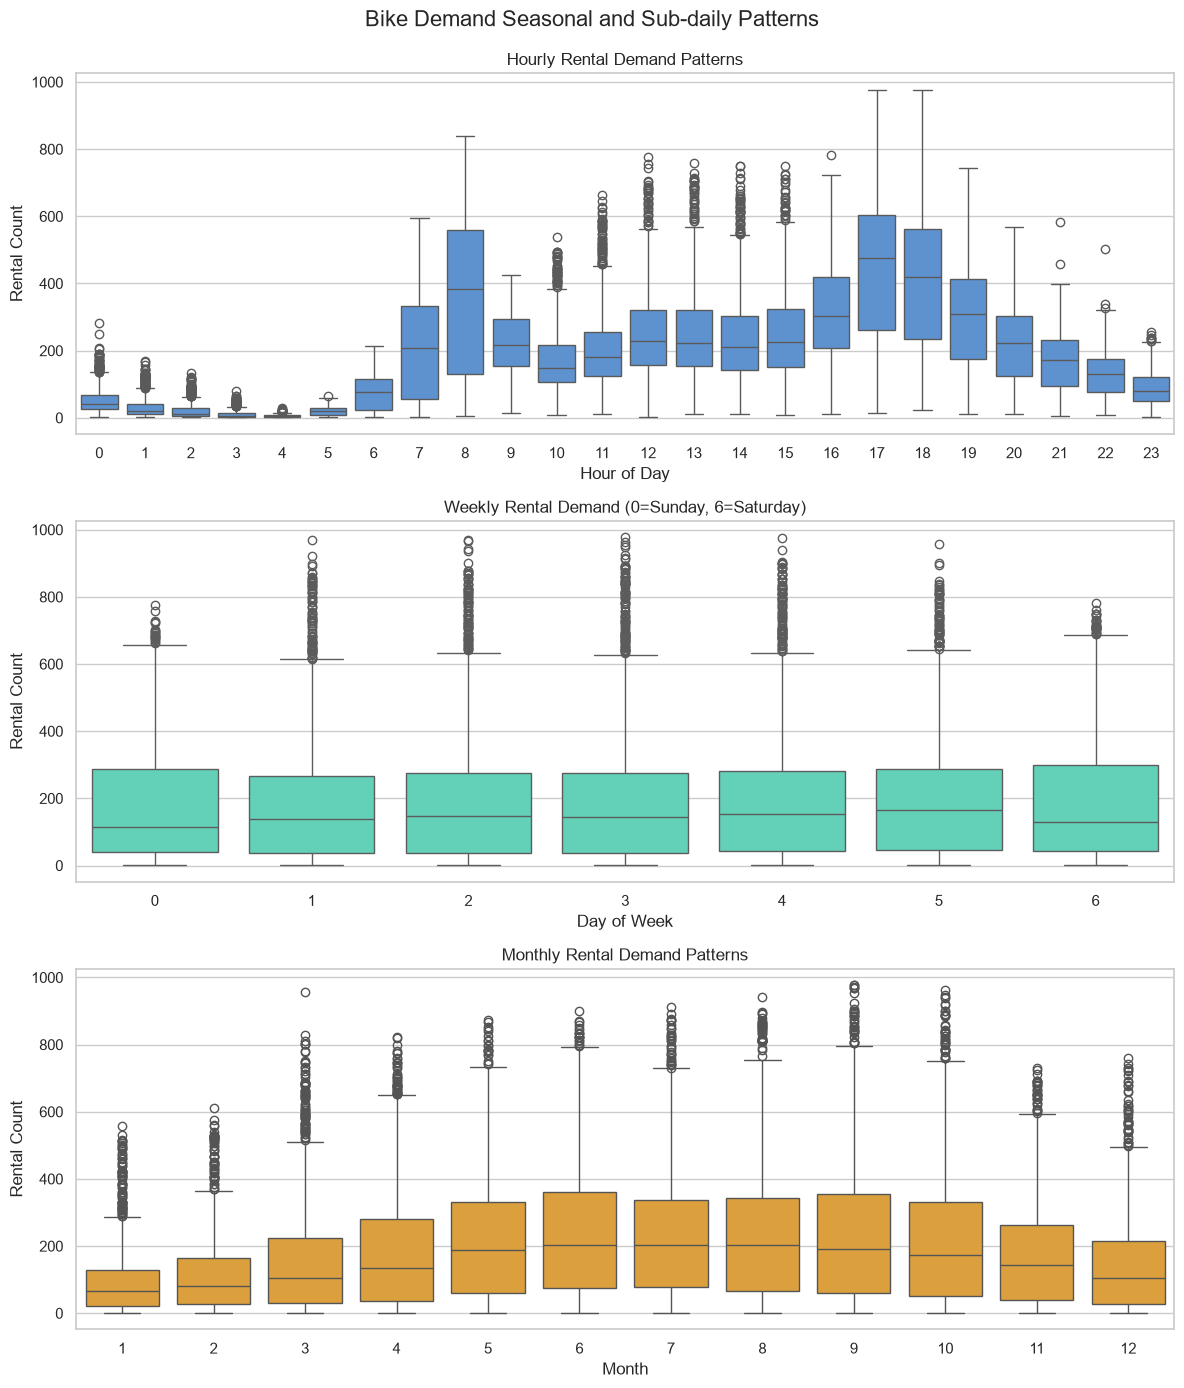

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

sns.boxplot(data=df, x='hr', y='cnt', ax=axes[0], color='#4a90e2')
axes[0].set_title('Hourly Rental Demand Patterns')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Rental Count')

sns.boxplot(data=df, x='weekday', y='cnt', ax=axes[1], color='#50e3c2')
axes[1].set_title('Weekly Rental Demand (0=Sunday, 6=Saturday)')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Rental Count')

sns.boxplot(data=df, x='mnth', y='cnt', ax=axes[2], color='#f5a623')
axes[2].set_title('Monthly Rental Demand Patterns')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Rental Count')

plt.suptitle('Bike Demand Seasonal and Sub-daily Patterns', y=0.99)
plt.tight_layout()
plt.show()


### 2.3 Interaction Heatmap (Hour vs Month)


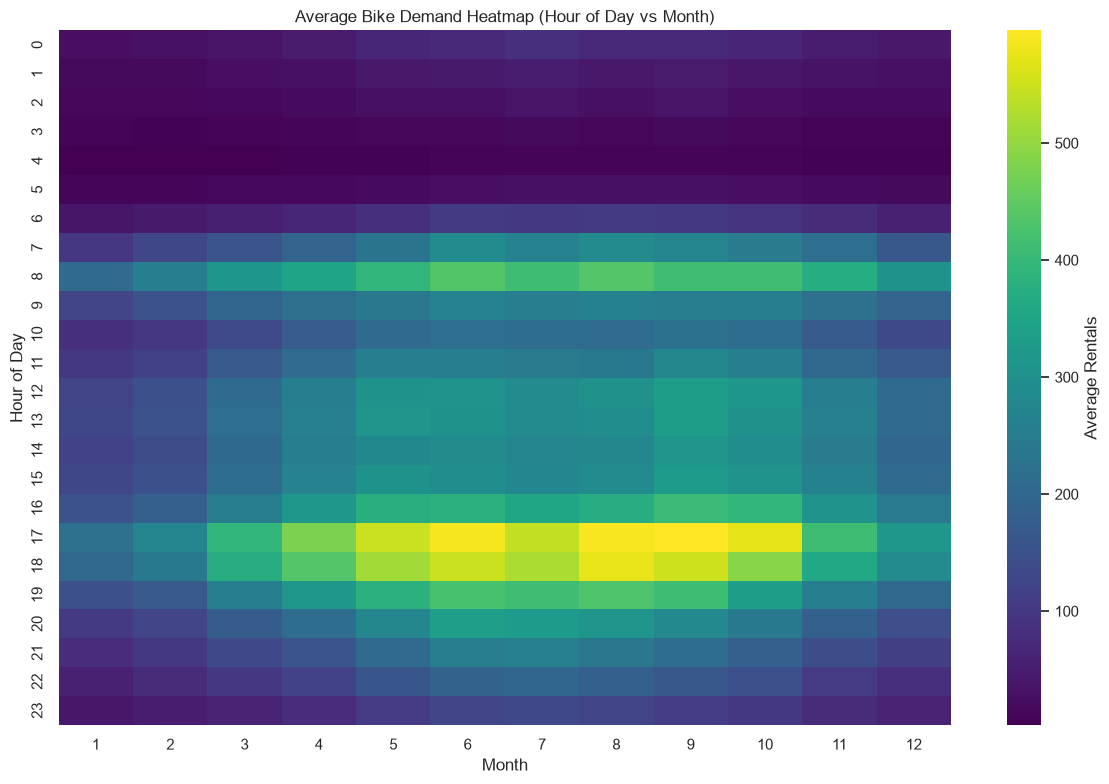

In [4]:
plt.figure(figsize=(12, 8))
pivot_df = df.pivot_table(values='cnt', index='hr', columns='mnth', aggfunc='mean')
sns.heatmap(pivot_df, cmap='viridis', annot=False, cbar_kws={'label': 'Average Rentals'})
plt.title('Average Bike Demand Heatmap (Hour of Day vs Month)')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()


### 2.4 Stationarity Check (Augmented Dickey-Fuller Test)


In [5]:
# We use a sample of 5000 points to speed up testing while retaining test properties
sample_data = df['cnt'].dropna()
adf_result = adfuller(sample_data.sample(n=min(5000, len(sample_data)), random_state=42))

print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")
print(f"Stationary (p-value < 0.05): {adf_result[1] < 0.05}")


Augmented Dickey-Fuller Test Results:
ADF Statistic: -47.2542
p-value: 0.0000e+00
Critical Values:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671
Stationary (p-value < 0.05): True


### 2.5 Autocorrelation Function (ACF) & Partial Autocorrelation Function (PACF)


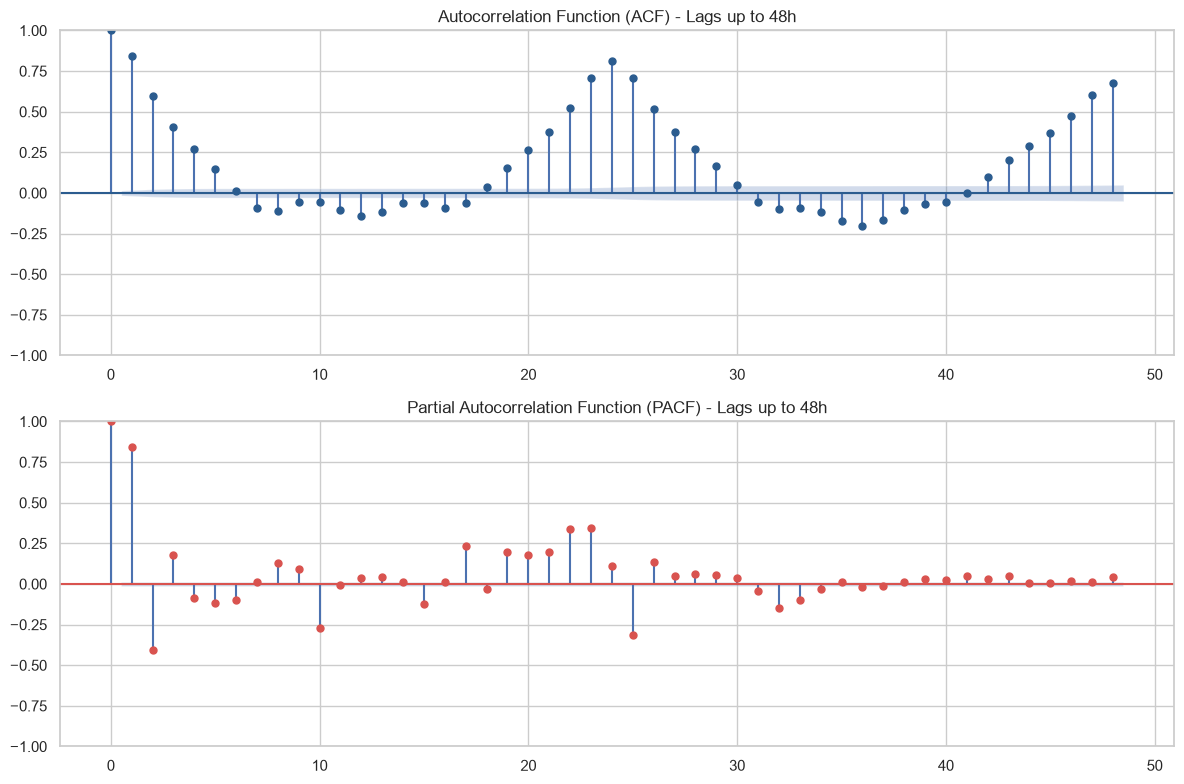

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['cnt'], lags=48, ax=axes[0], color='#2b5c8f', title='Autocorrelation Function (ACF) - Lags up to 48h')
plot_pacf(df['cnt'], lags=48, ax=axes[1], color='#d9534f', title='Partial Autocorrelation Function (PACF) - Lags up to 48h')
plt.tight_layout()
plt.show()


### 2.6 Time Series Decomposition


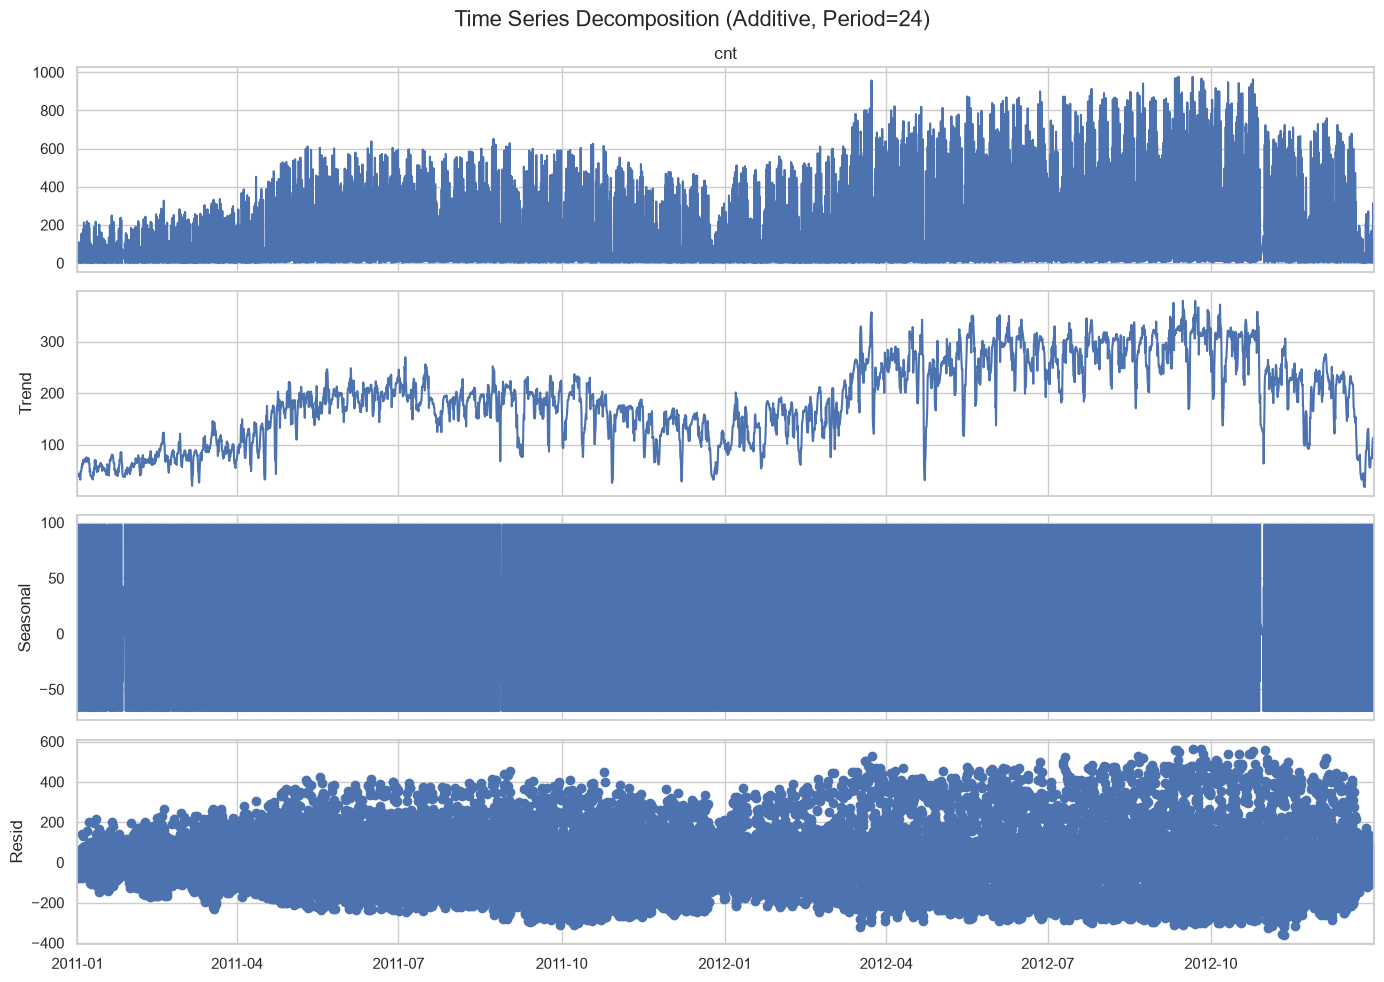

In [7]:
# Period=24 represents the daily cycle
decomp = seasonal_decompose(df['cnt'], model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition (Additive, Period=24)', y=0.98)
plt.tight_layout()
plt.show()


### 2.7 Anomaly Detection


Identified 55 anomaly points out of 17379 total data points (0.32%)


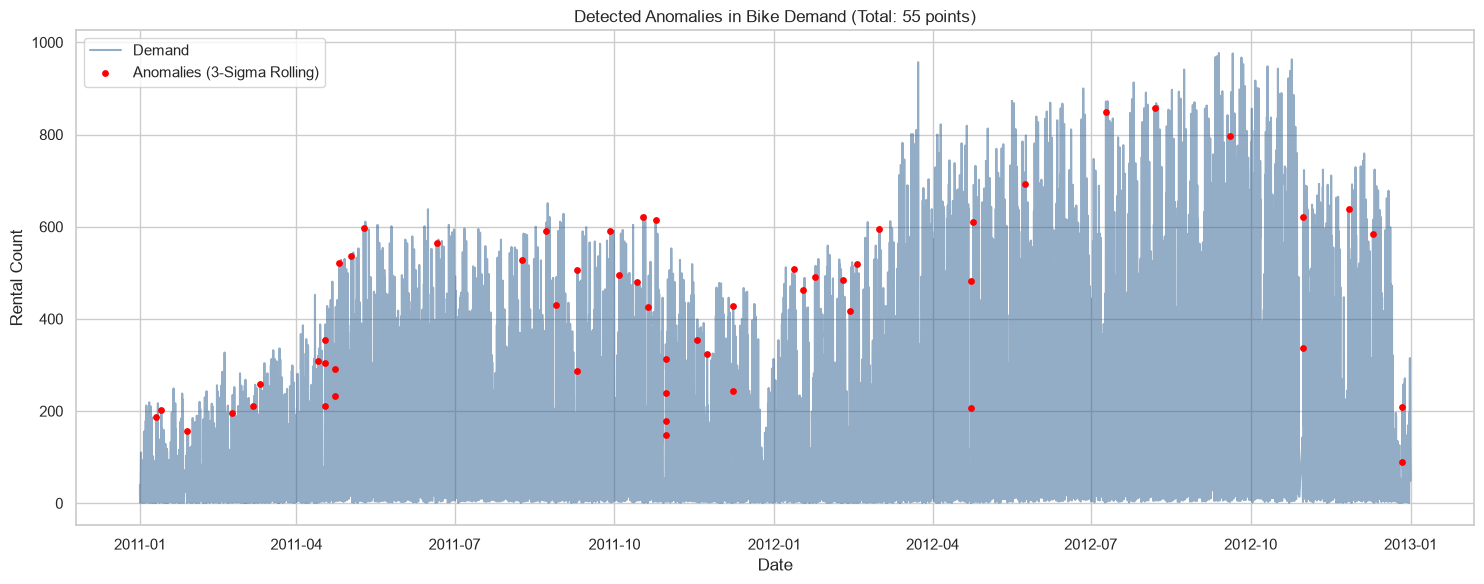

In [8]:
# Flag anomalies if demand lies beyond 3 rolling standard deviations from the 24h rolling mean
rolling_mean = df['cnt'].rolling(window=24, min_periods=1).mean()
rolling_std = df['cnt'].rolling(window=24, min_periods=1).std()

anomaly_mask = (df['cnt'] > rolling_mean + 3 * rolling_std) | (df['cnt'] < rolling_mean - 3 * rolling_std)
anomalies = df[anomaly_mask]

print(f"Identified {len(anomalies)} anomaly points out of {len(df)} total data points ({len(anomalies)/len(df)*100:.2f}%)")

# Plot the anomalies
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['cnt'], label='Demand', color='#2b5c8f', alpha=0.5)
plt.scatter(anomalies.index, anomalies['cnt'], color='red', label='Anomalies (3-Sigma Rolling)', s=15, zorder=5)
plt.title(f'Detected Anomalies in Bike Demand (Total: {len(anomalies)} points)')
plt.ylabel('Rental Count')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


## Section 3: Feature Engineering
To enable supervised learning models (Ridge Regression, XGBoost) to model temporal dependency, we engineer features according to the data pipeline design:
1. **Time-Based Features**: `hour`, `weekday`, and `workingday` extracted from index.
2. **Lag Features (Giving Memory)**: `lag_1h` (demand 1 hour before) and `lag_24h` (demand 24 hours before).
3. **Rolling Features**: `rolling_mean_3h` (3-hour rolling average is added to avoid random spikes).
*Note: To prevent data leakage, the rolling feature is shifted by 1 hour (so it only uses historical observations).*


In [9]:
# Time-based features
df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek
df['workingday'] = df['workingday'] # matches dataset column

# Lag features (giving memory)
df['lag_1h'] = df['cnt'].shift(1)
df['lag_24h'] = df['cnt'].shift(24)

# Rolling features (3h window to avoid random spikes, shifted by 1 to protect leakage)
df['rolling_mean_3h'] = df['cnt'].shift(1).rolling(window=3).mean()

# Drop rows with NaN values introduced by shift operations
df_clean = df.dropna()
print(f"Data shape after feature engineering and dropping NaNs: {df_clean.shape}")


Data shape after feature engineering and dropping NaNs: (17355, 21)


### 3.1 Feature Correlation Heatmap


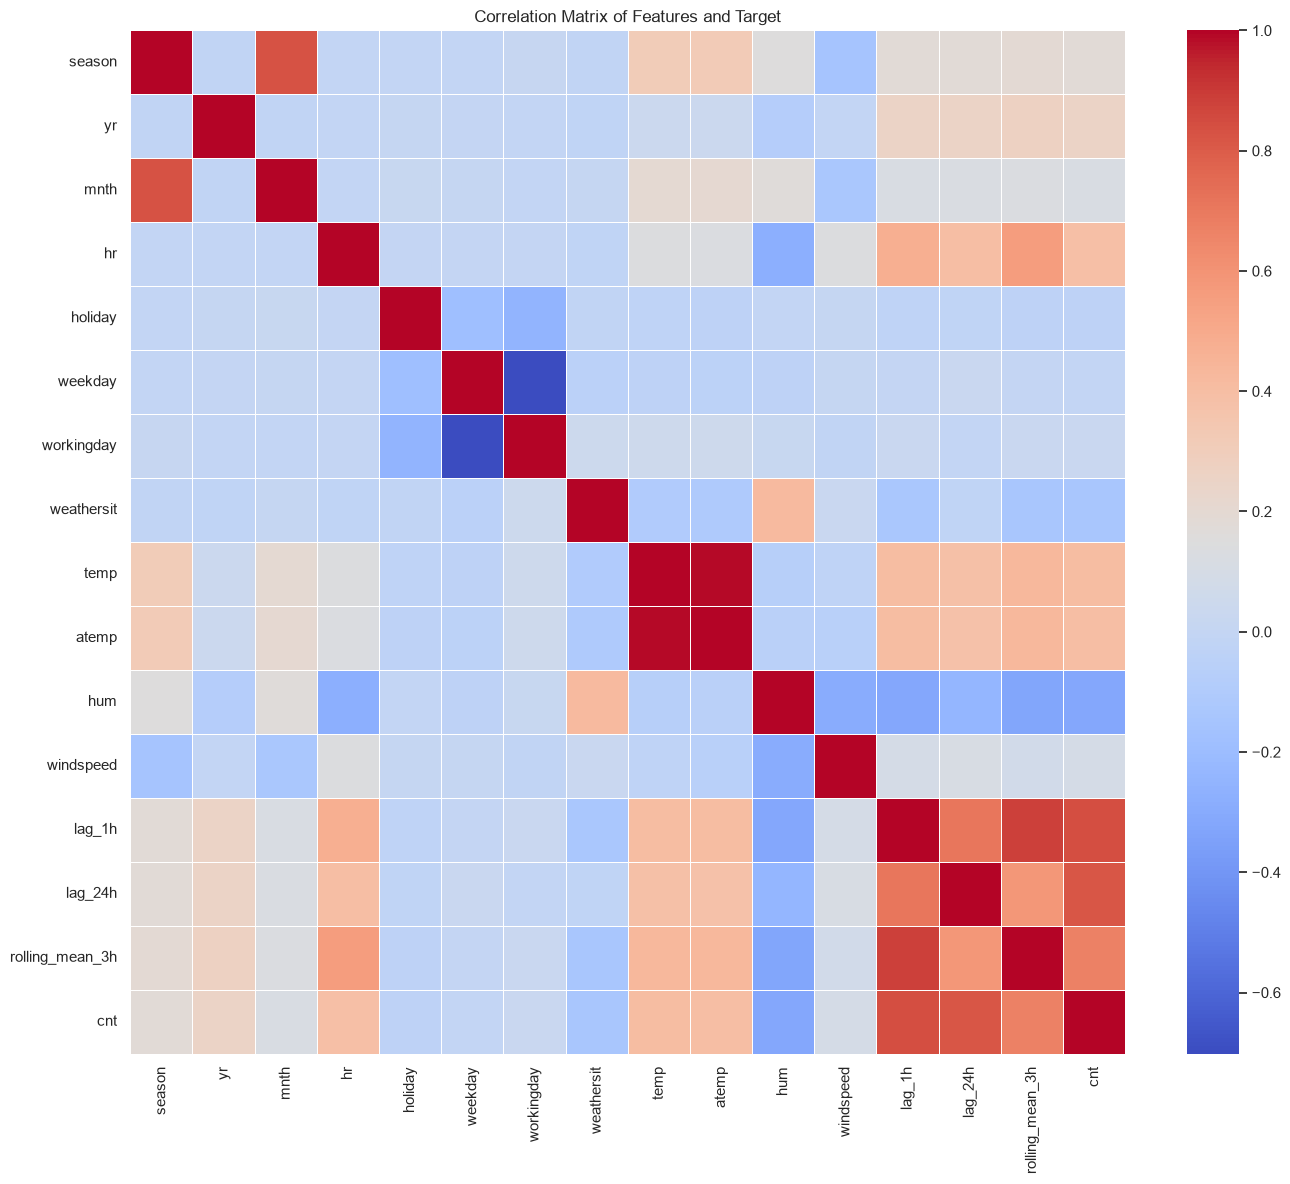

In [10]:
feature_cols = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit',
    'temp', 'atemp', 'hum', 'windspeed',
    'lag_1h', 'lag_24h', 'rolling_mean_3h', 'cnt'
]

plt.figure(figsize=(14, 12))
sns.heatmap(df_clean[feature_cols].corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Target')
plt.tight_layout()
plt.show()


## Section 4: Modeling & Validation
### 4.1 Chronological Split (Time-Aware Validation)
When dealing with time series, a random train/test split causes significant look-ahead bias (data leakage). We split the data strictly chronologically:
- **Train Set**: First 80% of data (approx. Jan 2011 to Aug 2012)
- **Test Set**: Last 20% of data (approx. Sep 2012 to Dec 2012)


In [11]:
# Split dataset
split_point = int(len(df_clean) * 0.80)
train_df = df_clean.iloc[:split_point]
test_df = df_clean.iloc[split_point:]

print(f"Train Set time range: {train_df.index.min()} to {train_df.index.max()} (Size: {len(train_df)})")
print(f"Test Set time range: {test_df.index.min()} to {test_df.index.max()} (Size: {len(test_df)})")

# Select predictors and target
predictors = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit',
    'temp', 'atemp', 'hum', 'windspeed',
    'lag_1h', 'lag_24h', 'rolling_mean_3h'
]
target = 'cnt'

X_train, y_train = train_df[predictors], train_df[target]
X_test, y_test = test_df[predictors], test_df[target]


Train Set time range: 2011-01-02 00:00:00 to 2012-08-07 16:00:00 (Size: 13884)
Test Set time range: 2012-08-07 17:00:00 to 2012-12-31 23:00:00 (Size: 3471)


### 4.2 Model Definitions & Training
We evaluate three models:
1. **Baseline Model (Naive)**: Predicts demand at time `t` is equal to demand at `t-24h` (the value of the lag_24h feature).
2. **Linear Regression (Ridge)**: Regularized linear model to capture linear trends and weather relationships.
3. **XGBoost Regressor**: Non-linear tree boosting model to capture complex seasonal interactions and non-linearities.


In [12]:
# 1. Baseline Model
y_pred_baseline = test_df['lag_24h']

# 2. Linear Regression with scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# 3. XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Training finished.")


Training finished.


## Section 5: Evaluation & Comparison
We evaluate all models using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).


In [13]:
metrics = {
    'Baseline (Lag 24h)': {
        'MAE': mean_absolute_error(y_test, y_pred_baseline),
        'RMSE': root_mean_squared_error(y_test, y_pred_baseline)
    },
    'Linear Regression (Ridge)': {
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'RMSE': root_mean_squared_error(y_test, y_pred_lr)
    },
    'XGBoost': {
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'RMSE': root_mean_squared_error(y_test, y_pred_xgb)
    }
}

metrics_df = pd.DataFrame(metrics).T
metrics_df


,MAE,RMSE
Baseline (Lag 24h),80.546816,134.852848
Linear Regression (Ridge),63.441994,93.165979
XGBoost,28.641397,45.688175


### 5.1 Forecast vs Actual Visual Comparison (2-Week Snapshot)


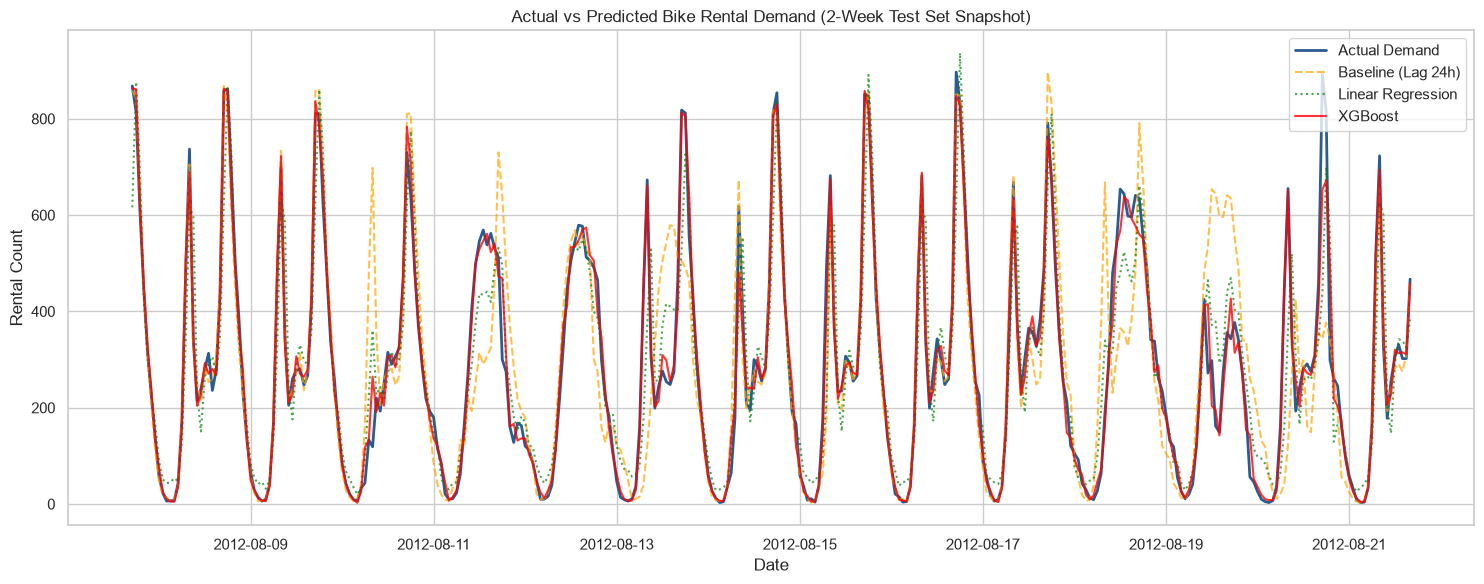

In [14]:
plt.figure(figsize=(15, 6))
test_snapshot = test_df.iloc[:336] # 2 weeks

plt.plot(test_snapshot.index, test_snapshot['cnt'], label='Actual Demand', color='#2b5c8f', linewidth=2)
plt.plot(test_snapshot.index, y_pred_baseline[:336], label='Baseline (Lag 24h)', color='orange', linestyle='--', alpha=0.7)
plt.plot(test_snapshot.index, y_pred_lr[:336], label='Linear Regression', color='green', linestyle=':', alpha=0.7)
plt.plot(test_snapshot.index, y_pred_xgb[:336], label='XGBoost', color='red', linewidth=1.5, alpha=0.8)

plt.title('Actual vs Predicted Bike Rental Demand (2-Week Test Set Snapshot)')
plt.ylabel('Rental Count')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


### 5.2 Feature Importance (XGBoost)


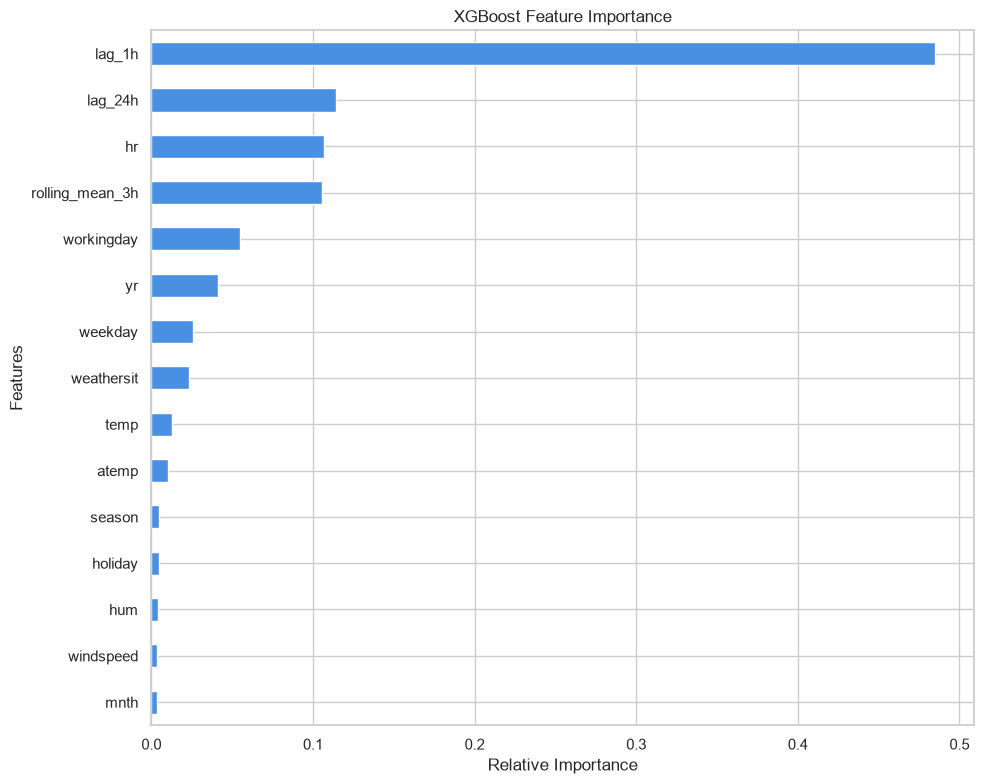

In [15]:
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=predictors).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='#4a90e2')
plt.title('XGBoost Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


### 5.3 XGBoost Residual Diagnostics


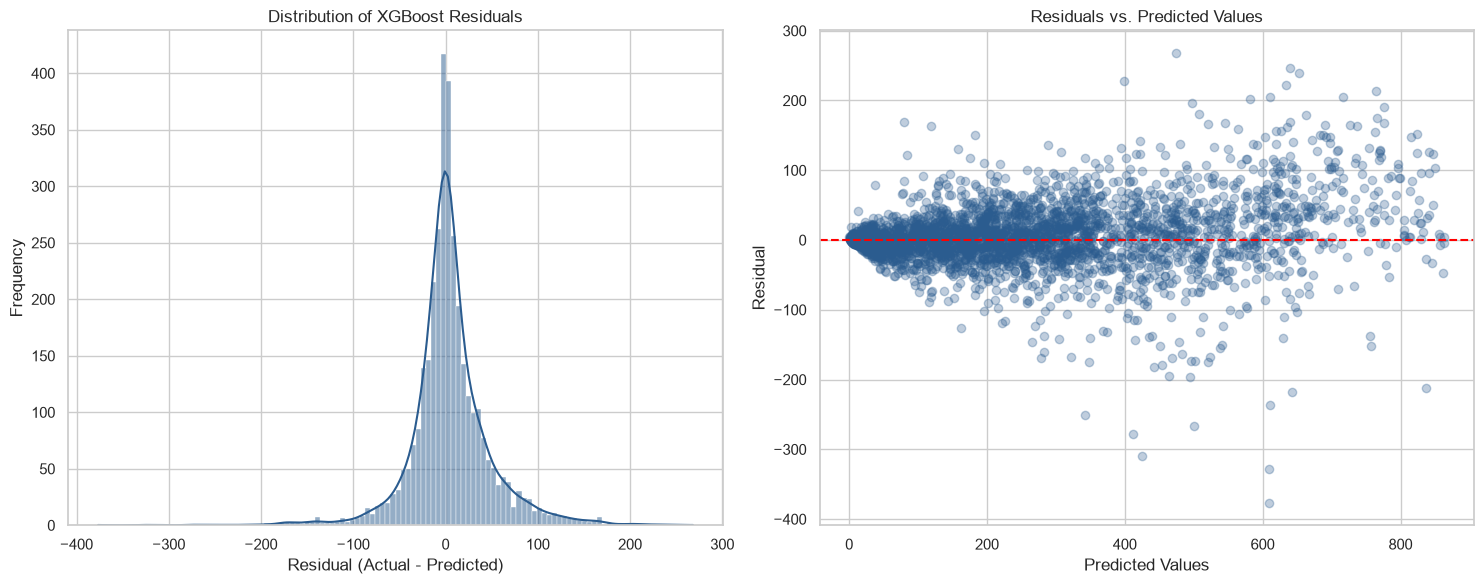

In [16]:
residuals = y_test - y_pred_xgb
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
sns.histplot(residuals, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Distribution of XGBoost Residuals')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(y_pred_xgb, residuals, alpha=0.3, color='#2b5c8f')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## Section 6: Key Findings & Conclusions
1. **Model Comparison**:
   - **XGBoost** achieves the best performance, significantly reducing error relative to both the naive baseline and Linear Regression.
   - The naive baseline is a very strong benchmark in hourly forecasting, showing that demand is highly cyclic.
2. **Key Drivers**:
   - As shown by the feature importance, **lag_1h**, **lag_24h**, and time features (especially **hour**) are critical predictors, reflecting strong auto-regressive properties and daily cyclical patterns.
   - Environmental factors (temperature and humidity) also play important roles in regulating the demand.
